# Population Model Evaluation

Population-level cache-backed model performance and fold/tissue difficulty analysis.


In [24]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.eval_population import *


In [25]:
import importlib
import src.eval_utils.eval_population as eval_population
importlib.reload(eval_population)
from src.eval_utils.eval_population import *


In [26]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',  # or 'out/loro_subject_cache_arxiv'
    gene_scope='allgenes',
    plam_cache_dirname='plam',
)
CFG
print('analysis scope:', CFG.gene_scope)

analysis scope: allgenes


## Shared Reconstruction

`PREPOST` is rebuilt here because fold-combo and held-out-region summaries need target metadata and observed-region structure.


In [6]:
PREPOST = prepare_pre_post_harmonization(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


subjects: 318
genes: 13618
parcels: 150


## 3) Global Prediction Tables

Build or load the canonical all-gene wide evaluation tables. The truth table and each model prediction table share identical `subject_region_key` row order.

In [27]:
import importlib
import src.eval_utils.eval_population as eval_population
importlib.reload(eval_population)
from src.eval_utils.eval_population import *


In [21]:
import importlib
import src.eval_utils.eval_style as eval_style
import src.eval_utils.eval_population as eval_population

importlib.reload(eval_style)
importlib.reload(eval_population)
from src.eval_utils.eval_population import *

MODELS = ['naive', 'dlam', 'plam']
N_JOBS = 16
CACHE_GLOBAL_TABLES = True
FORCE_REBUILD_GLOBAL_TABLES = False
EVAL_GENE_LIST_PATH = None  # e.g. 'data/raw/gene_lists/ahba_100hvg.txt'

SCATTER_COLOR_BY = 'region_group'  # none | region_group | region | subject | gene
SCATTER_TOP_N = 12
SCATTER_MAX_POINTS_PER_MODEL = 10_000
SCATTER_KWS = dict(
    max_points_per_model=SCATTER_MAX_POINTS_PER_MODEL,
    axis_limit_quantiles=(0.05, 0.995),
    point_size=1,
    alpha=0.45,
    rasterized=True,
)


In [29]:
truth_df, pred_dfs, global_manifest = build_global_prediction_tables(
    cfg=CFG,
    prepost=PREPOST,
    models=MODELS,
    cache=CACHE_GLOBAL_TABLES,
    force_rebuild=FORCE_REBUILD_GLOBAL_TABLES,
    n_jobs=N_JOBS,
)

manifest_summary = {
    k: global_manifest.get(k)
    for k in [
        'created_at_utc',
        'cache_dir',
        'source_cache_root',
        'gene_scope',
        'models',
        'truth_expression_space',
        'prediction_expression_space',
        'gtex_rep_mode',
        'gtex_hemi_mode',
        'n_rows',
        'n_genes',
        'n_subjects',
        'n_parcels',
    ]
}
display(pd.Series(manifest_summary, name='global_eval_manifest'))
display(truth_df.head())
print({model: df.shape for model, df in pred_dfs.items()})


created_at_utc                                  2026-04-29T23:28:21.294132+00:00
cache_dir                      /scratch/asr655/neuroinformatics/Seq2GeneEx/gt...
source_cache_root                                         out/loro_subject_cache
gene_scope                                                              allgenes
models                                                       [naive, dlam, plam]
truth_expression_space                                                harmonized
prediction_expression_space                                           harmonized
gtex_rep_mode                                                           centroid
gtex_hemi_mode                                                       mirror_left
n_rows                                                                      2820
n_genes                                                                    13618
n_subjects                                                                   313
n_parcels                   

,subject,age,sex,subject_region_key,parcel_idx,gtex_region,ahba_region,region_group,gtex_coordinates_raw,gtex_rep_x,...,MRM1,HIST1H4A,GOLGA6L10,HIST1H2AM,HIST1H4B,HIST1H3H,MRPL45,PCDH20,PAGR1,TMEM265
0,GTEX-1117F,64,F,GTEX-1117F|5,5,brain - cerebellar hemisphere,Cerebellar_Region5,cerebellar,"[(-26.04206099, -53.60357518, -51.26077813), (...",-33.487977,...,2.943969,1.561887,3.505472,4.470888,4.863447,2.127437,5.699000,1.250517,6.218362,3.250597
1,GTEX-1117F,64,F,GTEX-1117F|10,10,brain - caudate (basal ganglia),LH-Ca,subcortical,"[(-13.71428571, 6.556257901390637, 8.983565107...",-14.216461,...,3.217235,1.506255,3.542502,4.555119,4.862676,1.319629,5.581843,3.912728,6.362165,3.091069
2,GTEX-1117F,64,F,GTEX-1117F|18,18,brain - nucleus accumbens (basal ganglia),LH-NAC,subcortical,"[(-9.566666667, 7.900000000000006, -9.53333333...",-9.934848,...,3.291385,1.506969,3.492359,4.798620,4.864834,1.686910,5.499541,4.284439,6.362572,3.103423
3,GTEX-1117F,64,F,GTEX-1117F|19,19,brain - putamen (basal ganglia),LH-Pu,subcortical,"[(-25.11581292, 0.3563474387527776, 0.59910913...",-25.496385,...,3.244307,1.506277,3.575236,4.810700,4.862178,1.487257,5.653855,3.580846,6.368560,3.076855
4,GTEX-1117F,64,F,GTEX-1117F|29,29,brain - amygdala,LH_Amygdala,subcortical,"[(-23.28113879, -4.555160142, -19.82918149), (...",-23.590901,...,2.908304,1.506248,3.545862,4.516249,4.863857,2.449167,5.933543,2.875592,6.387455,3.082352


{'naive': (2820, 13636), 'dlam': (2820, 13636), 'plam': (2820, 13636)}


## 4) Global Scatter

The scatter samples from the full all-gene prediction field for visibility. Metrics below are computed sample-wise, so each held-out subject-region sample contributes evenly.

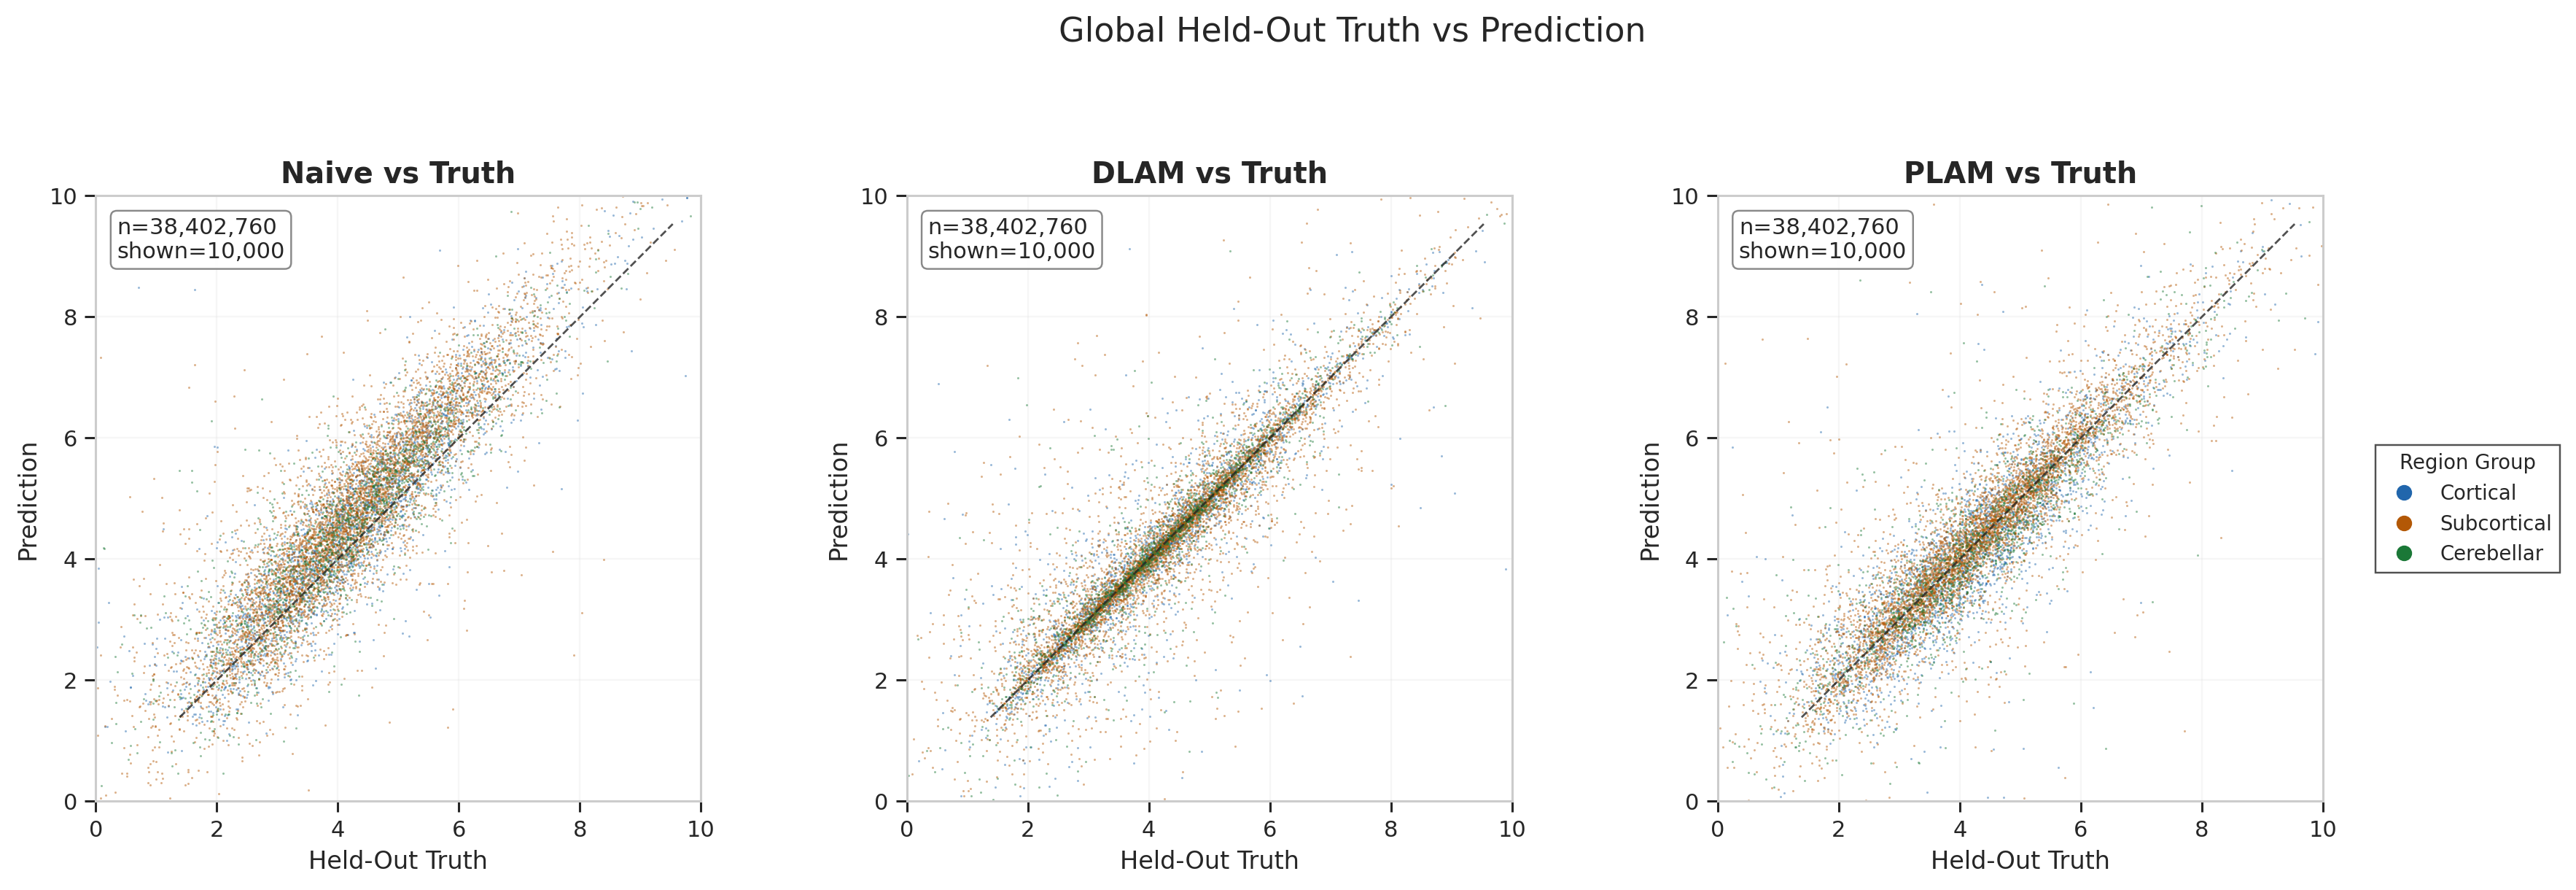

In [30]:
global_view = make_prediction_eval_view(
    truth_df=truth_df,
    pred_dfs=pred_dfs,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    models=MODELS,
)

fig, axes = plot_global_prediction_scatter(
    global_view,
    color_by=SCATTER_COLOR_BY,
    top_n=SCATTER_TOP_N,
    **SCATTER_KWS,
)


## 5) Sample-Wise Global Metrics

Default unit is `sample`: each `subject_region_key` is scored across genes, then metrics are summarized across samples.

In [16]:
import importlib
import src.eval_utils.eval_population as eval_population
importlib.reload(eval_population)
from src.eval_utils.eval_population import *

In [ ]:
sample_metrics, sample_summary = compute_prediction_metrics(
    global_view,
    unit='sample',
    
    stratify_by=None,
    metrics=('pearson_r', 'spearman_r', 'r2', 'rmse'),
)

display(sample_summary.sort_values(['metric', 'model']))
display(sample_metrics.head())


KeyError: 'regions'

,count,mean,std,min,25%,50%,75%,max
comparison,,,,,,,,
DLAM - Naive fill,2820.0,0.016145,0.107539,-0.437545,-0.004655,0.042862,0.078341,0.219491
PLAM - DLAM,2820.0,-0.001683,0.037067,-0.113670,-0.026524,-0.006499,0.014411,0.163180
PLAM - Naive fill,2820.0,0.014462,0.086329,-0.369459,-0.000458,0.028022,0.063885,0.217237


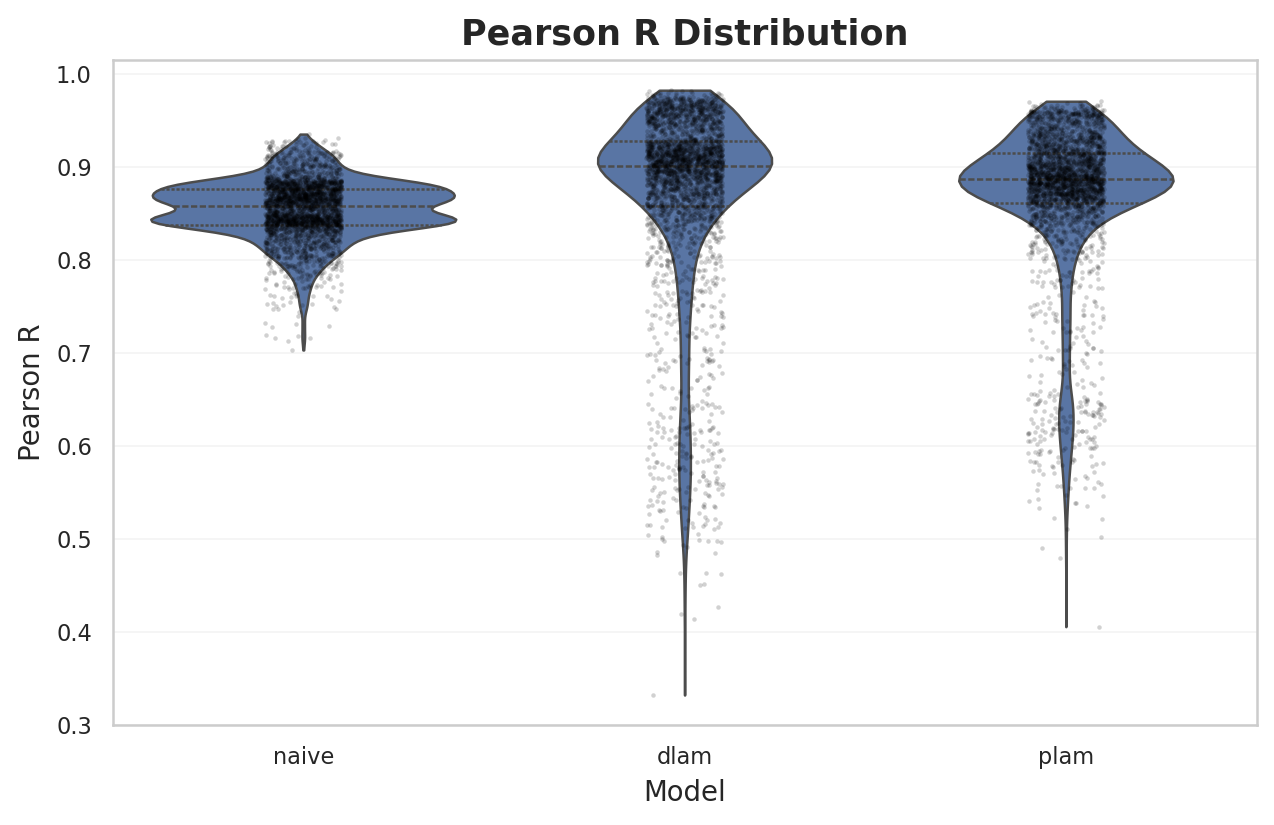

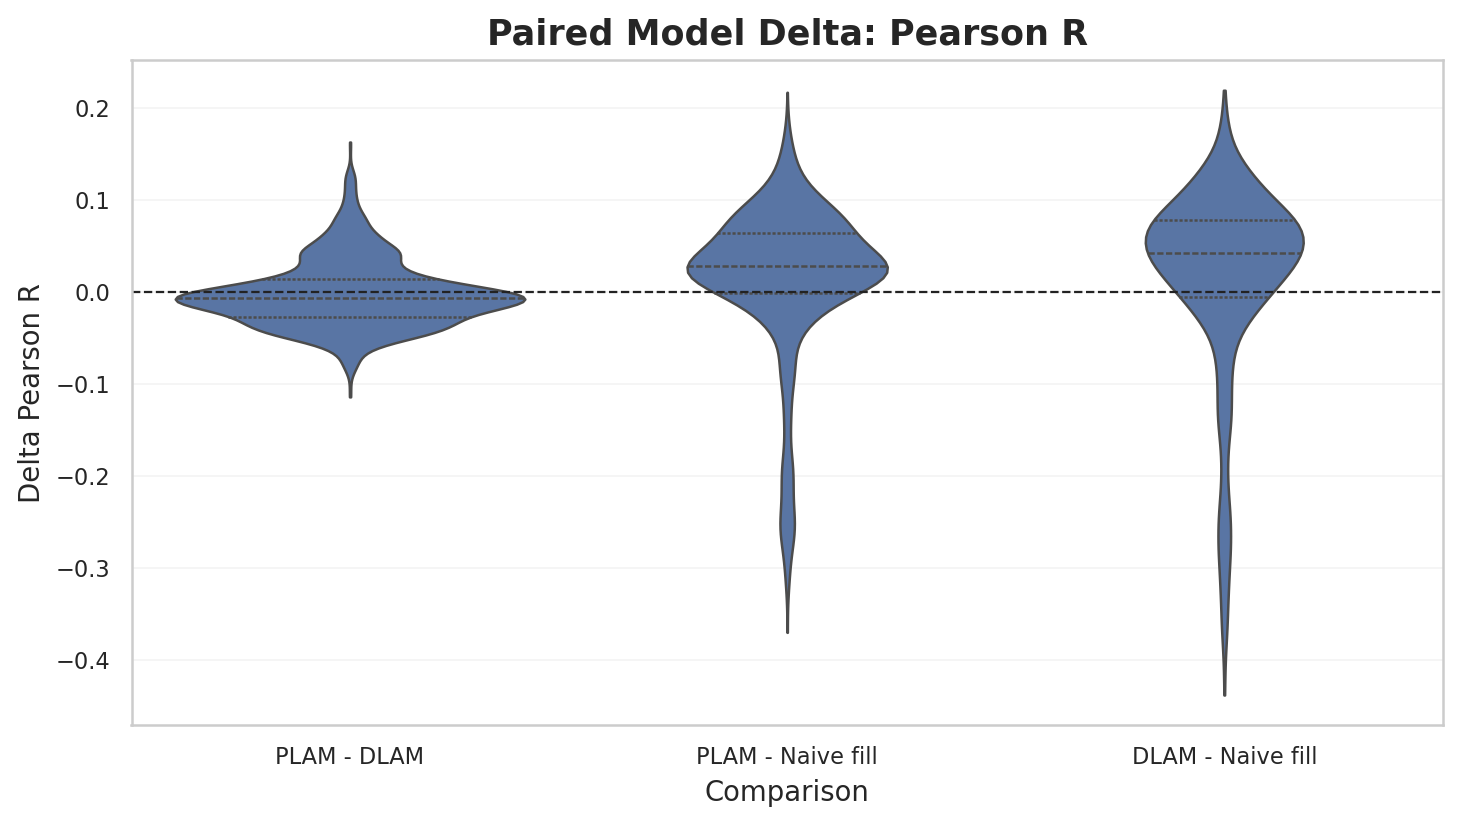

In [14]:
fig, ax = plot_metric_violins(
    sample_metrics,
    metric='pearson_r',
    x='model',
    order=MODELS,
)

fig, ax, delta_df = plot_metric_delta_violins(
    sample_metrics,
    metric='pearson_r',
)
display(delta_df.groupby('comparison')['delta'].describe())


## 6) Region-Group Stratified Metrics

Region-group summaries keep the same sample-wise metric unit, then aggregate samples within cortical, subcortical, and cerebellar groups.

In [ ]:
region_metrics, region_summary = compute_prediction_metrics(
    global_view,
    unit='sample',
    stratify_by='region_group',
    metrics=('pearson_r', 'spearman_r', 'r2', 'rmse'),
)

display(region_summary.sort_values(['metric', 'stratum', 'model']))

fig, ax = plot_metric_violins(
    region_metrics,
    metric='pearson_r',
    x='region_group',
    hue='model',
    order=['cortical', 'subcortical', 'cerebellar'],
    figsize=(9.2, 4.8),
)

fig, ax, region_heatmap = plot_region_model_metric_heatmap(
    region_summary,
    metric='pearson_r',
    stratify_by='region_group',
)
display(region_heatmap)


## 7) Coverage vs Performance

Subject coverage is the number of observed GTEx regions for the subject. This checks whether sample-wise performance shifts with subject-level observation coverage.

,subject,model,subject_coverage,pearson_r
0,GTEX-1117F,dlam,9,0.884513
1,GTEX-1117F,naive,9,0.895686
2,GTEX-1117F,plam,9,0.885462
3,GTEX-111FC,dlam,11,0.887445
4,GTEX-111FC,naive,11,0.854270


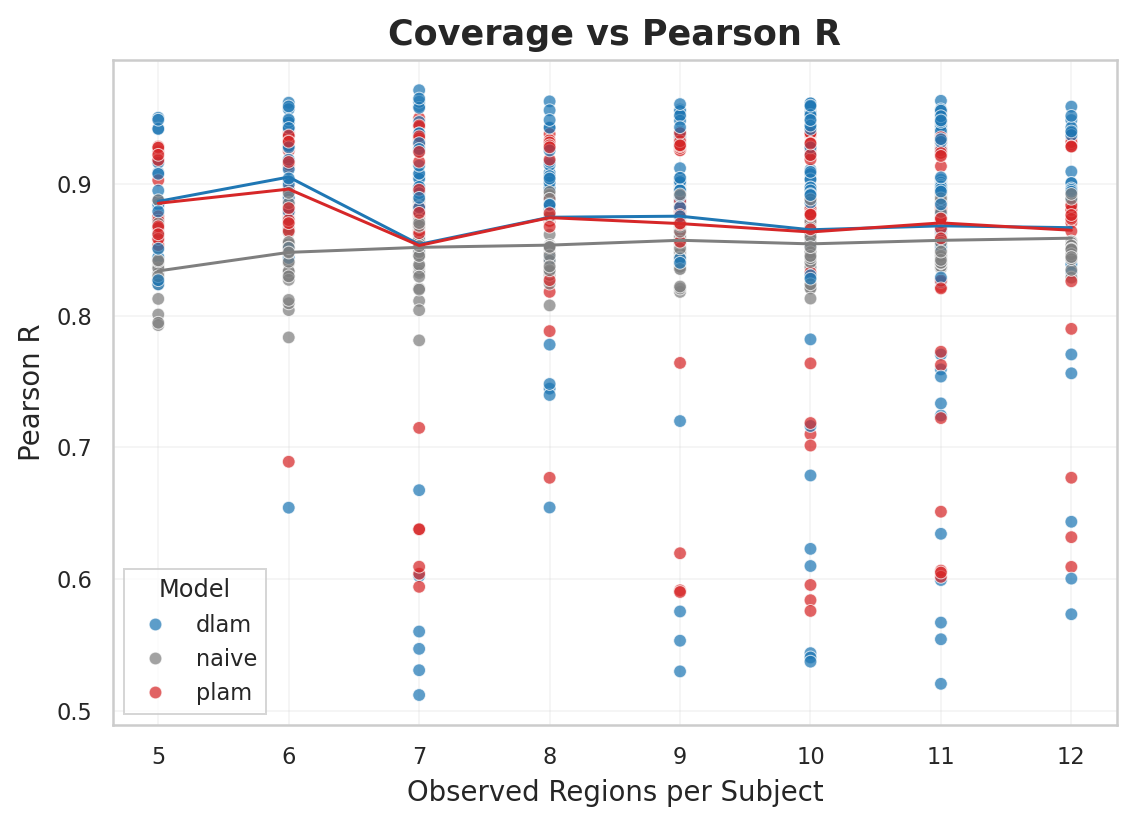

In [15]:
fig, ax, coverage_plot_df = plot_coverage_vs_metric(
    sample_metrics,
    metric='pearson_r',
)
display(coverage_plot_df.head())
